<a href="https://colab.research.google.com/github/Chaitanya15-ai/codealpha_datascience/blob/main/Codealpha_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (768, 7)

Columns:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Summary Statistics:
                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00         

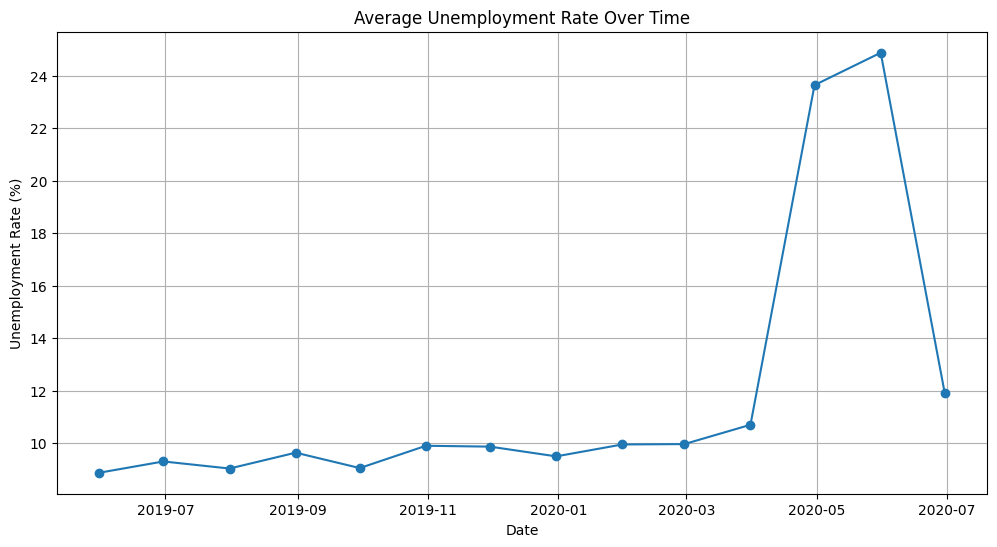

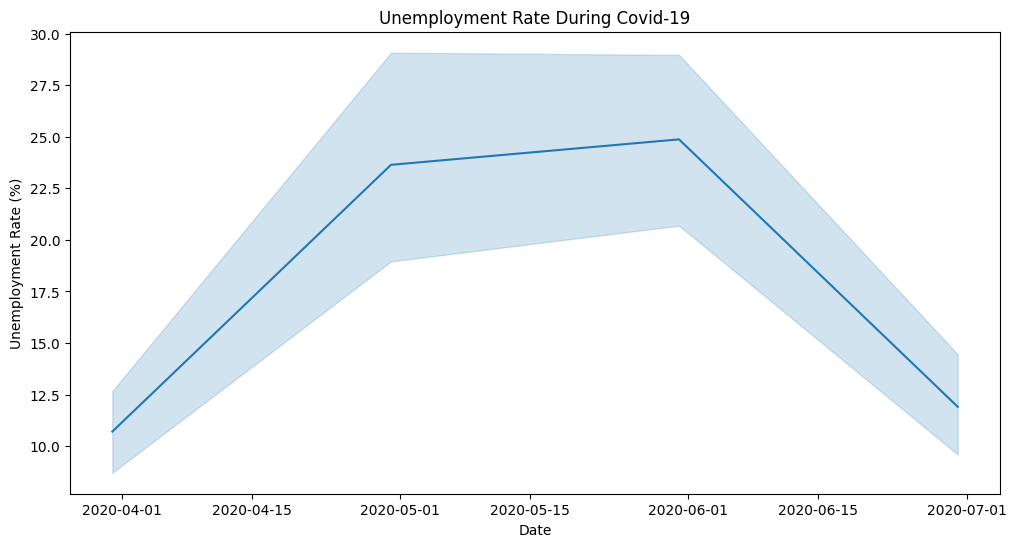

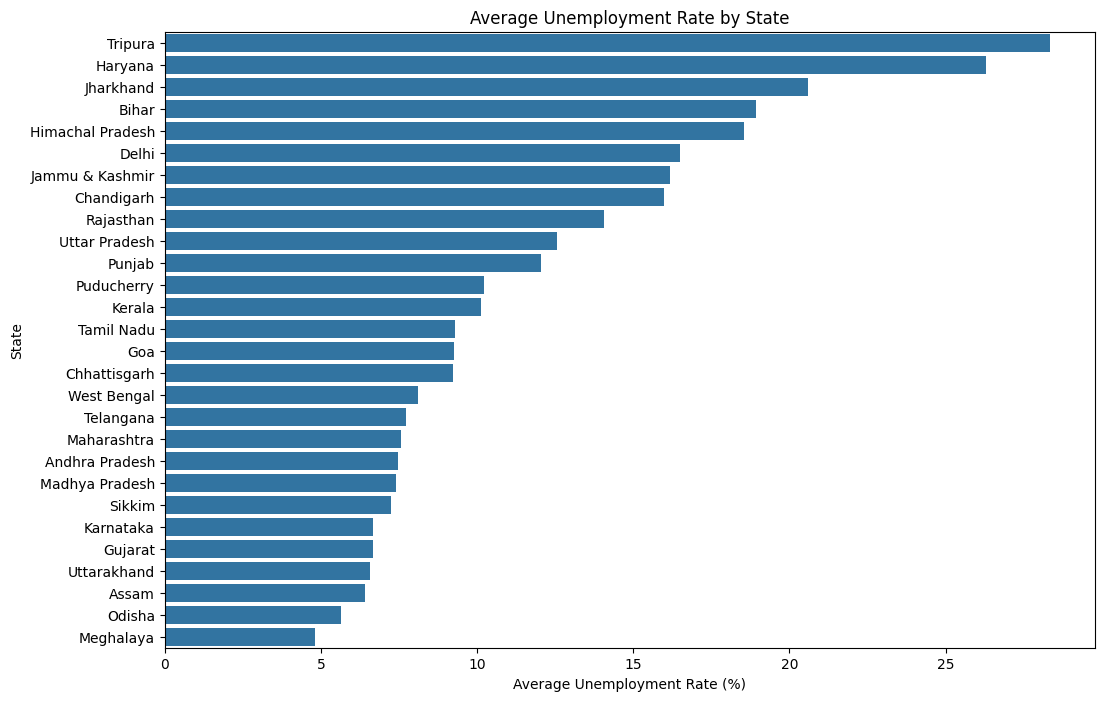

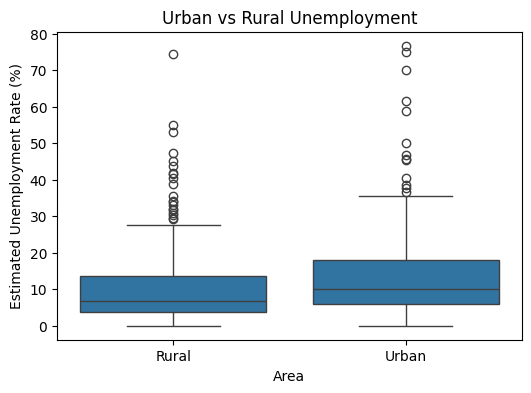

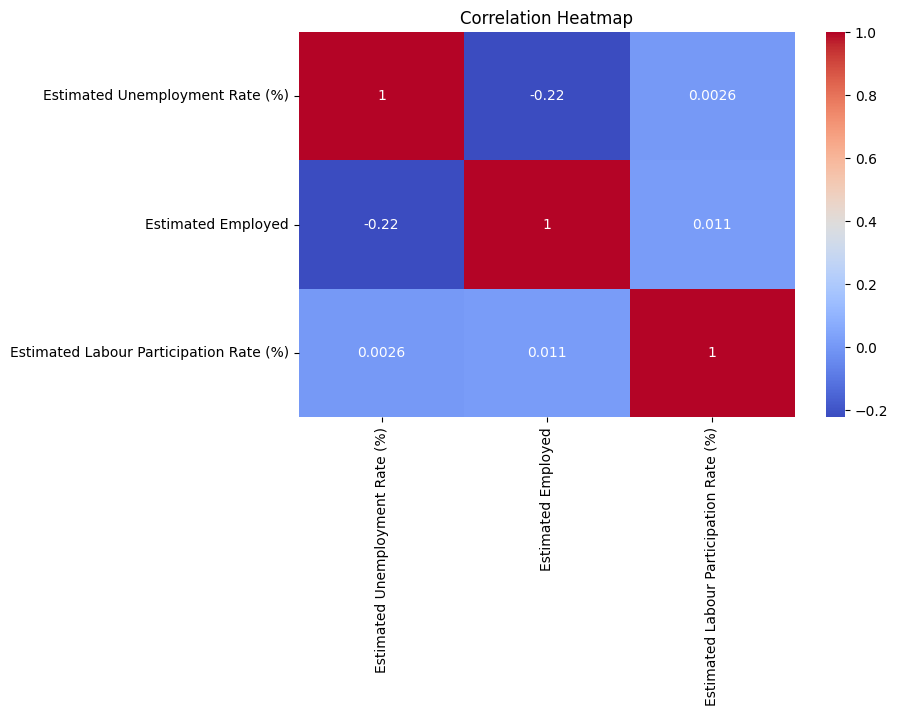


Top 10 States by Average Unemployment Rate:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Unemployment in India.csv")

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

plt.figure(figsize=(12,6))
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker='o'
)

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

covid_period = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(12,6))
sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=covid_period
)

plt.title("Unemployment Rate During Covid-19")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

state_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.barplot(
    x=state_unemployment.values,
    y=state_unemployment.index
)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(
    df[
        [
            'Estimated Unemployment Rate (%)',
            'Estimated Employed',
            'Estimated Labour Participation Rate (%)'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

print("\nTop 10 States by Average Unemployment Rate:")
print(state_unemployment.head(10))